##0. Импорты и загрузка данных

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv("/content/weatherAUS.csv")

In [4]:
df.shape

(76113, 23)

##1. EDA

In [5]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


В данных присуствует временная метка формата ymd, преобразуем ее в 4 признака winter, spring, summer, autumn (то есть one hot кодирование времени года)

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else: # 9, 10, 11
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
season_dummies = pd.get_dummies(df['Season'], dtype=int)
df = pd.concat([df, season_dummies], axis=1)

df.drop(['Date', 'Month', 'Season'], axis=1, inplace=True)
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Autumn,Spring,Summer,Winter
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,8.0,NaN,16.9,21.8,No,No,0,0,0,1
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,NaN,NaN,17.2,24.3,No,No,0,0,0,1
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,NaN,2.0,21.0,23.2,No,No,0,0,0,1
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,NaN,NaN,18.1,26.5,No,No,0,0,0,1
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,7.0,8.0,17.8,29.7,No,No,0,0,0,1


In [7]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Autumn,Spring,Summer,Winter
count,75001.000000,75175.000000,73884.000000,37280.000000,30464.000000,69991.000000,74732.000000,74118.000000,74292.000000,73864.000000,65523.000000,65576.000000,46036.000000,45078.000000,74632.000000,74150.000000,76113.000000,76113.000000,76113.000000,76113.000000
mean,11.271084,22.257790,2.360311,5.212366,7.327101,40.245032,13.952858,18.564532,71.145978,52.196022,1018.249551,1015.881810,4.619472,4.700963,15.808057,20.808707,0.241890,0.263424,0.251967,0.242718
std,6.226131,6.935675,8.293909,4.149631,3.842799,14.389752,9.420504,9.390574,17.848594,20.730859,7.106027,6.979618,2.906949,2.691976,6.050791,6.743509,0.428231,0.440493,0.434146,0.428729
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,3.000000,1.000000,980.500000,979.000000,0.000000,0.000000,-7.200000,-5.400000,0.000000,0.000000,0.000000,0.000000
25%,6.800000,17.500000,0.000000,2.400000,4.400000,30.000000,7.000000,11.000000,59.000000,37.000000,1013.500000,1011.200000,1.000000,2.000000,11.500000,16.300000,0.000000,0.000000,0.000000,0.000000
50%,11.400000,21.800000,0.000000,4.400000,8.100000,39.000000,13.000000,17.000000,72.000000,52.000000,1018.300000,1016.000000,6.000000,5.000000,16.000000,20.400000,0.000000,0.000000,0.000000,0.000000
75%,16.100000,26.600000,0.600000,7.000000,10.400000,48.000000,19.000000,24.000000,85.000000,66.000000,1023.000000,1020.600000,7.000000,7.000000,20.300000,25.000000,0.000000,1.000000,1.000000,0.000000
max,31.900000,47.300000,371.000000,145.000000,14.500000,135.000000,130.000000,83.000000,100.000000,100.000000,1040.600000,1037.900000,9.000000,8.000000,37.700000,46.700000,1.000000,1.000000,1.000000,1.000000


На первый взгляд в данных нет каких-либо выбросов или иных странностей

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76113 entries, 0 to 76112
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       76113 non-null  object 
 1   MinTemp        75001 non-null  float64
 2   MaxTemp        75175 non-null  float64
 3   Rainfall       73884 non-null  float64
 4   Evaporation    37280 non-null  float64
 5   Sunshine       30464 non-null  float64
 6   WindGustDir    69983 non-null  object 
 7   WindGustSpeed  69991 non-null  float64
 8   WindDir9am     69197 non-null  object 
 9   WindDir3pm     73308 non-null  object 
 10  WindSpeed9am   74732 non-null  float64
 11  WindSpeed3pm   74118 non-null  float64
 12  Humidity9am    74292 non-null  float64
 13  Humidity3pm    73864 non-null  float64
 14  Pressure9am    65523 non-null  float64
 15  Pressure3pm    65576 non-null  float64
 16  Cloud9am       46036 non-null  float64
 17  Cloud3pm       45078 non-null  float64
 18  Temp9a

In [9]:
df.isnull().sum()

,0
Location,0
MinTemp,1112
MaxTemp,938
Rainfall,2229
Evaporation,38833
Sunshine,45649
WindGustDir,6130
WindGustSpeed,6122
WindDir9am,6916
WindDir3pm,2805


У некоторых признаков отствует вплоть до половины значений

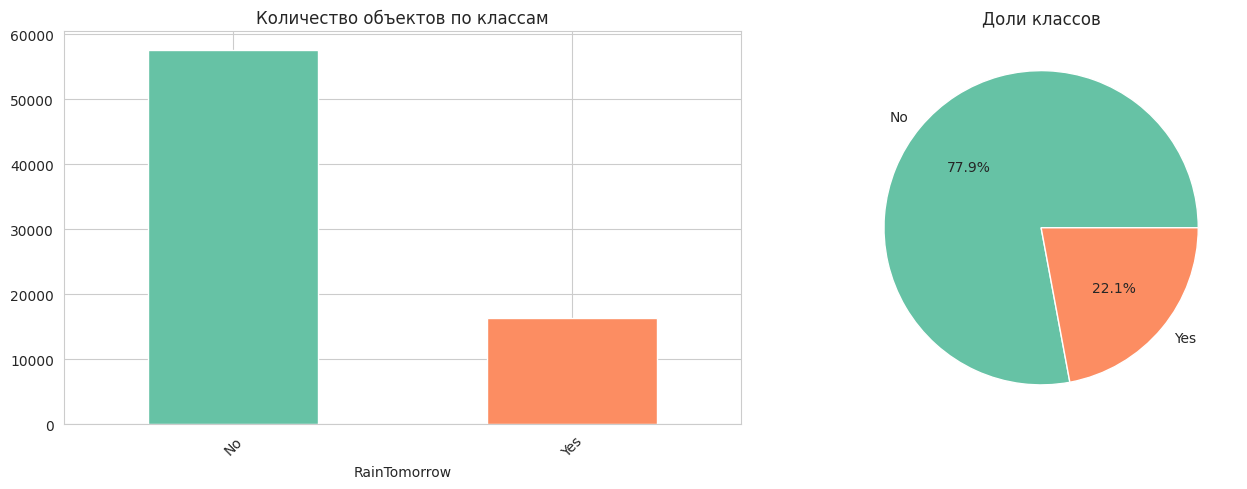

In [10]:
target = 'RainTomorrow'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Классы плохо сбалансированы

Будем предсказывать класс RainTomorrow, поэтому необходимо посмотреть сохранит ли таргет распределение при удалении пропусков

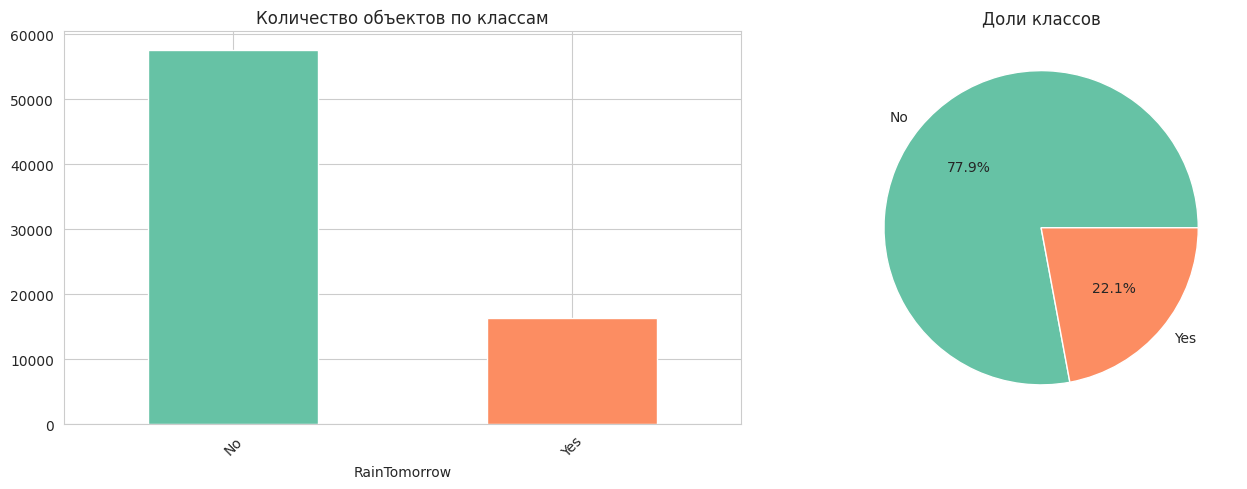

In [11]:
df = df.dropna(subset=[target])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Распределение осталось тем же, посмотрим как изменилось количество пропусков по другим признакам

In [12]:
df.isnull().sum()

,0
Location,0
MinTemp,436
MaxTemp,213
Rainfall,901
Evaporation,37678
Sunshine,44213
WindGustDir,5503
WindGustSpeed,5496
WindDir9am,6560
WindDir3pm,2517


Стало чуть получше, но у некоторых признаков все еще нет половины значений

###1.1. Числовые признаки

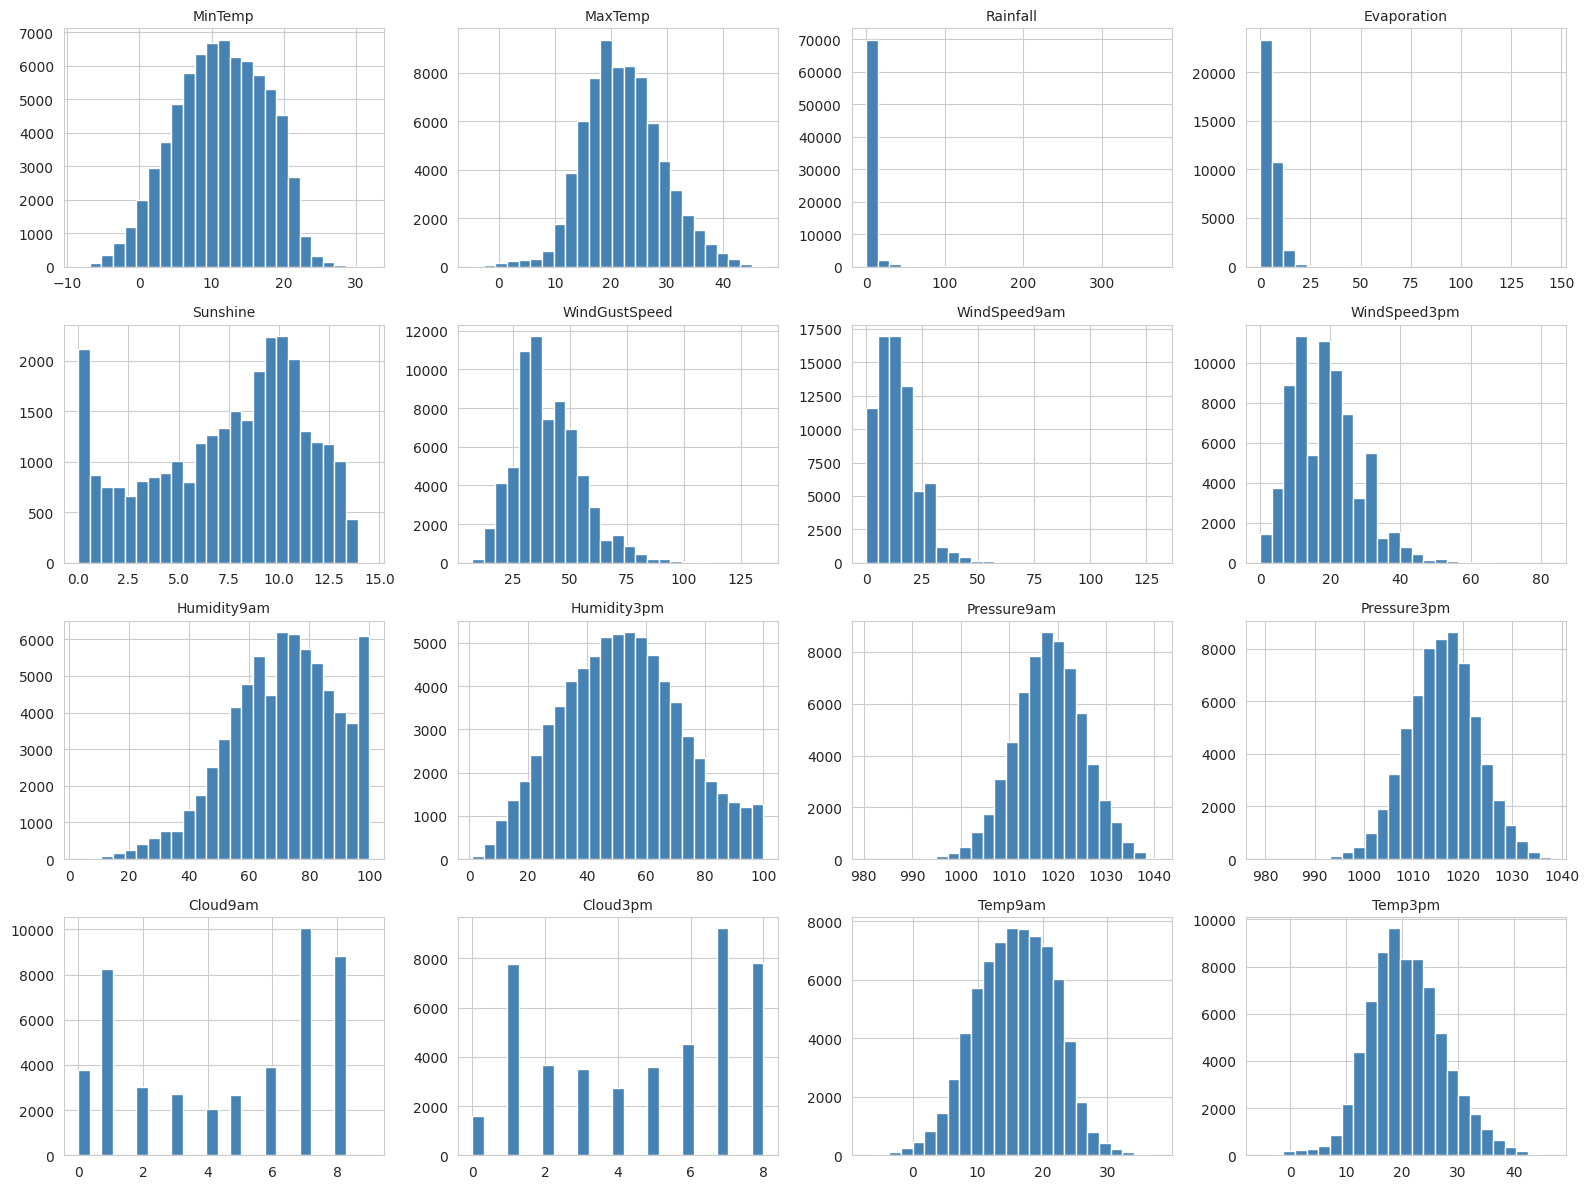

In [15]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['Autumn', 'Spring', 'Summer', 'Winter']).columns.tolist()

n_cols = 4
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=25, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Некоторые признаки распределены почти нормально

Признаки, связанные с облаками, на самом деле являются категориальными и описывают тип облаков. Их рассматривать не будем

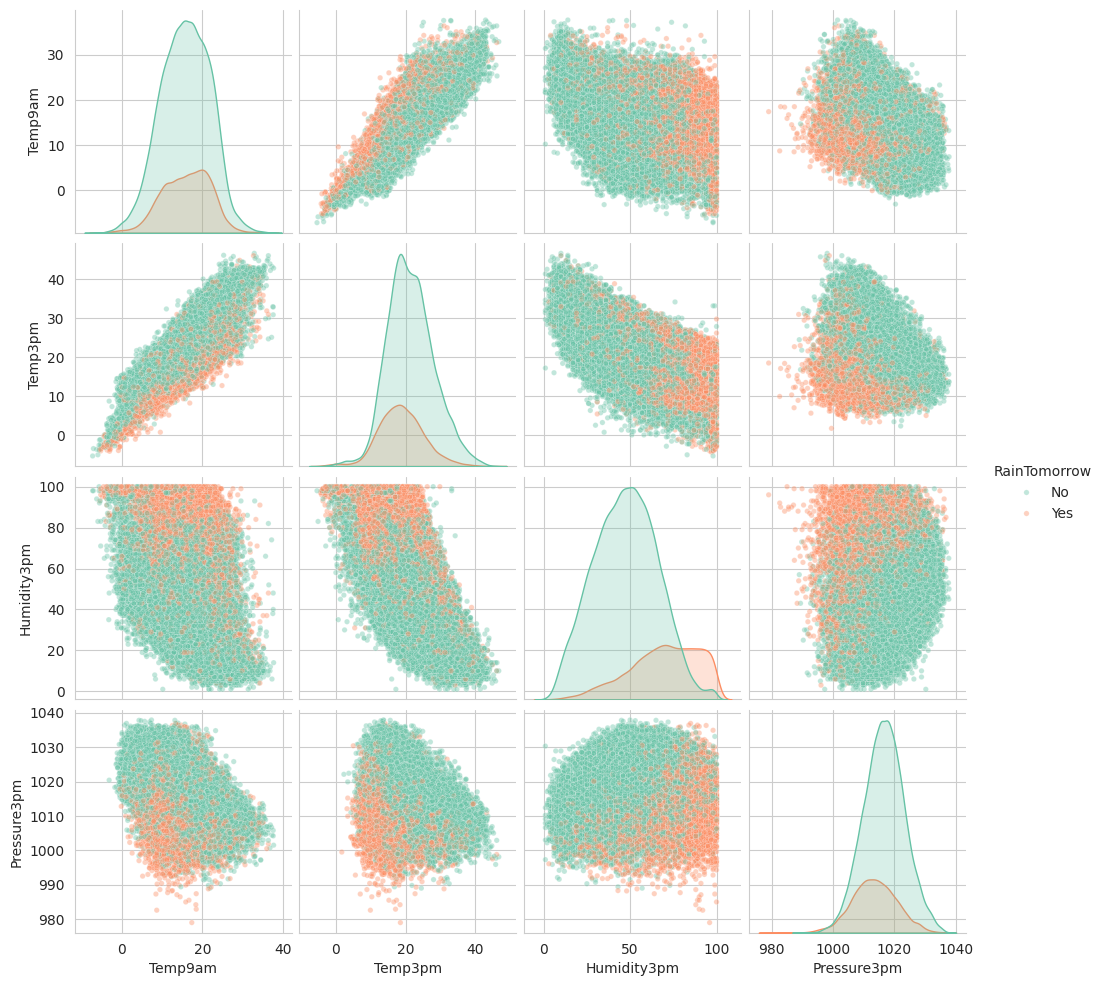

In [16]:
sns.pairplot(df[['Temp9am', 'Temp3pm', 'Humidity3pm', 'Pressure3pm', target]],
             hue=target, palette='Set2', plot_kws={'alpha': 0.4, 's': 15})
plt.show()

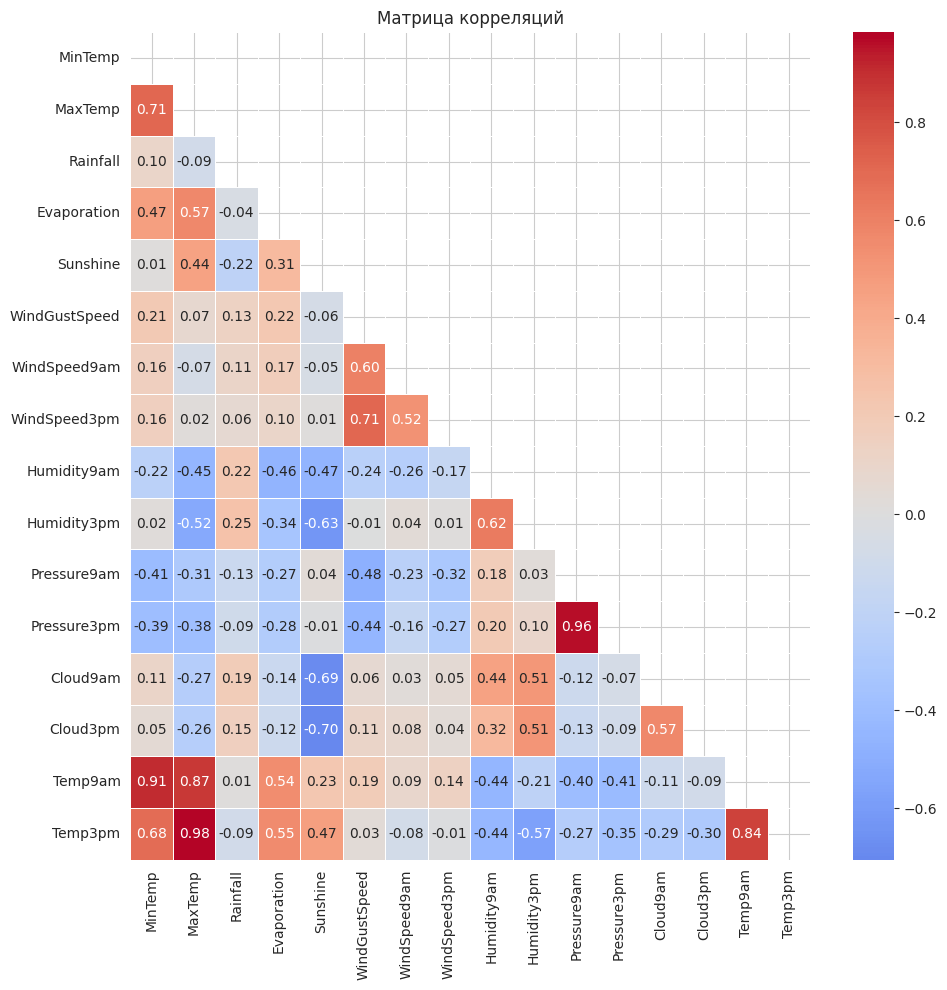

In [17]:
plt.figure(figsize=(10, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

Сильно скоррелированы следующие пары:  
pressure9am - pressure3pm  
maxtemp - temp3pm  
mintemp - temp9am  
maxtemp - mintemp  
temp9am - temp3pm  
Все эти корреляции вполне согласуются с физическими соображениями

Более того, облачные признаки имеют заметную отрицательную корреляцию с sunshine - удалим их

In [18]:
df.drop(['Cloud9am', 'Cloud3pm'], axis=1, inplace=True)
numeric_cols.remove('Cloud9am')
numeric_cols.remove('Cloud3pm')

###1.2. Категориальные признаки

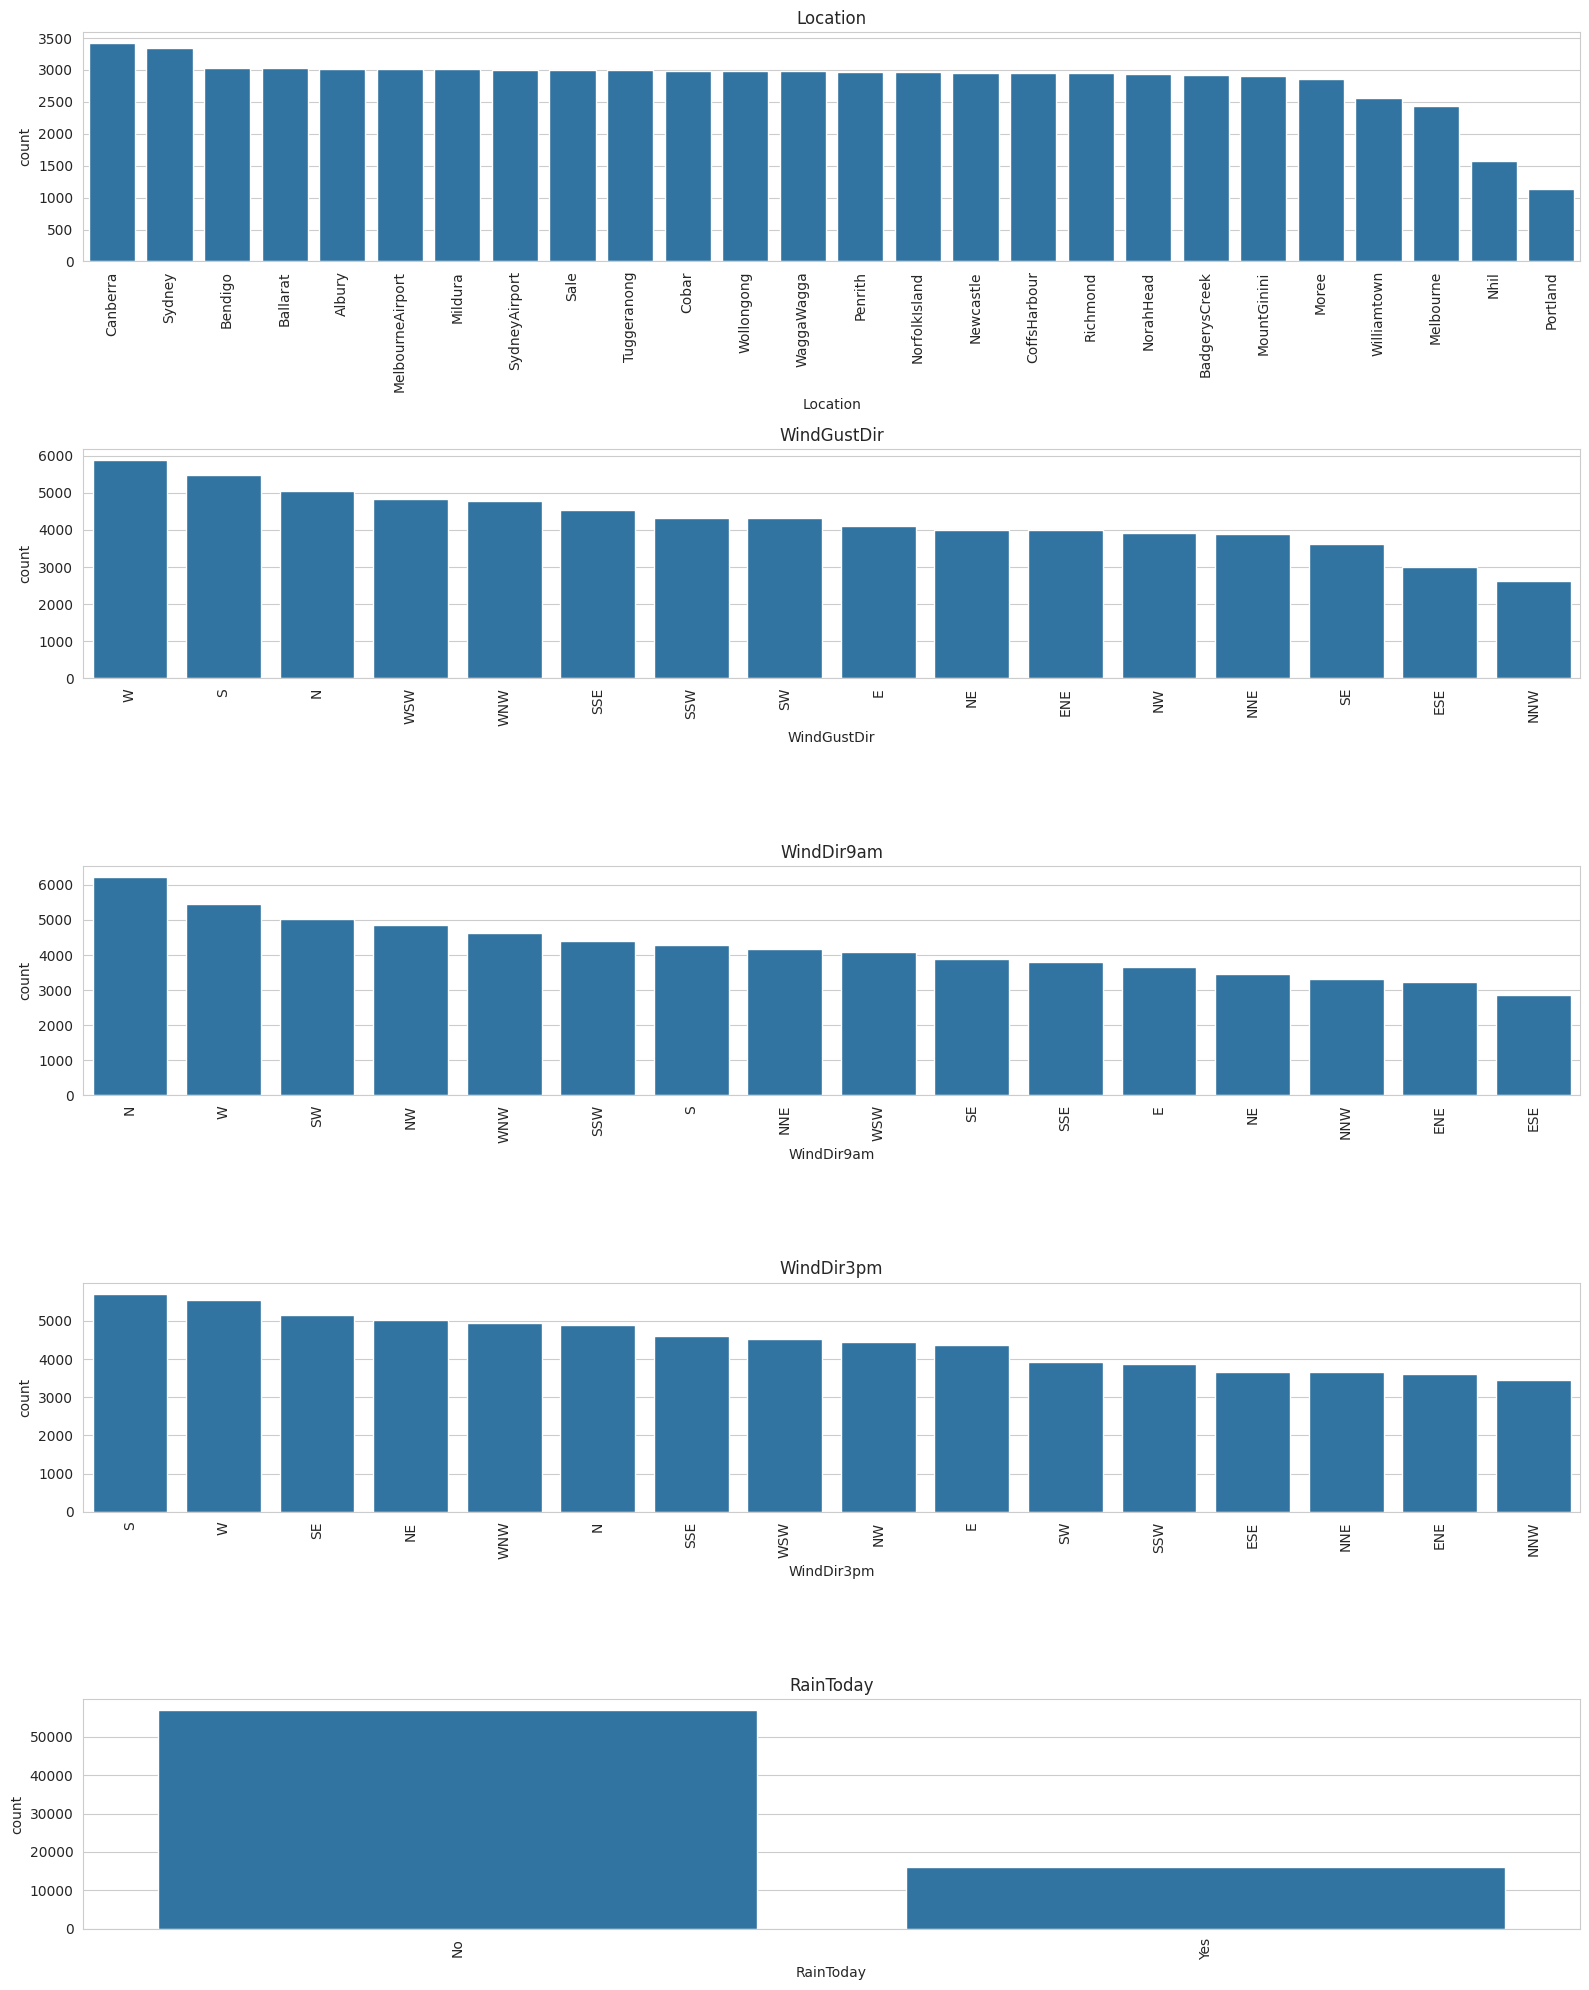

In [19]:
categorical_cols = df.select_dtypes(include=object).columns.tolist()

categorical_cols = [col for col in categorical_cols if col not in ['RainTomorrow']]

n_cols = 1
n_rows = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Признак Location можно было бы закодировать отрезками по частоте дождей, но тогда количество категориальных бинарных признаков станет очень большим, поэтому выкинем этот признак

In [20]:
df.drop('Location', axis=1, inplace=True)

##2. Работа с пропусками

In [21]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols_with_nan = df[numeric_cols].columns[df[numeric_cols].isnull().any()].tolist()
season_columns = ['Winter', 'Spring', 'Summer', 'Autumn']

for col in numeric_cols_with_nan:
    for season_col in season_columns:
        season_mean = df.loc[df[season_col] == True, col].mean()
        df.loc[(df[season_col] == True) & (df[col].isnull()), col] = season_mean
df.isnull().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,5503
WindGustSpeed,0
WindDir9am,6560
WindDir3pm,2517
WindSpeed9am,0


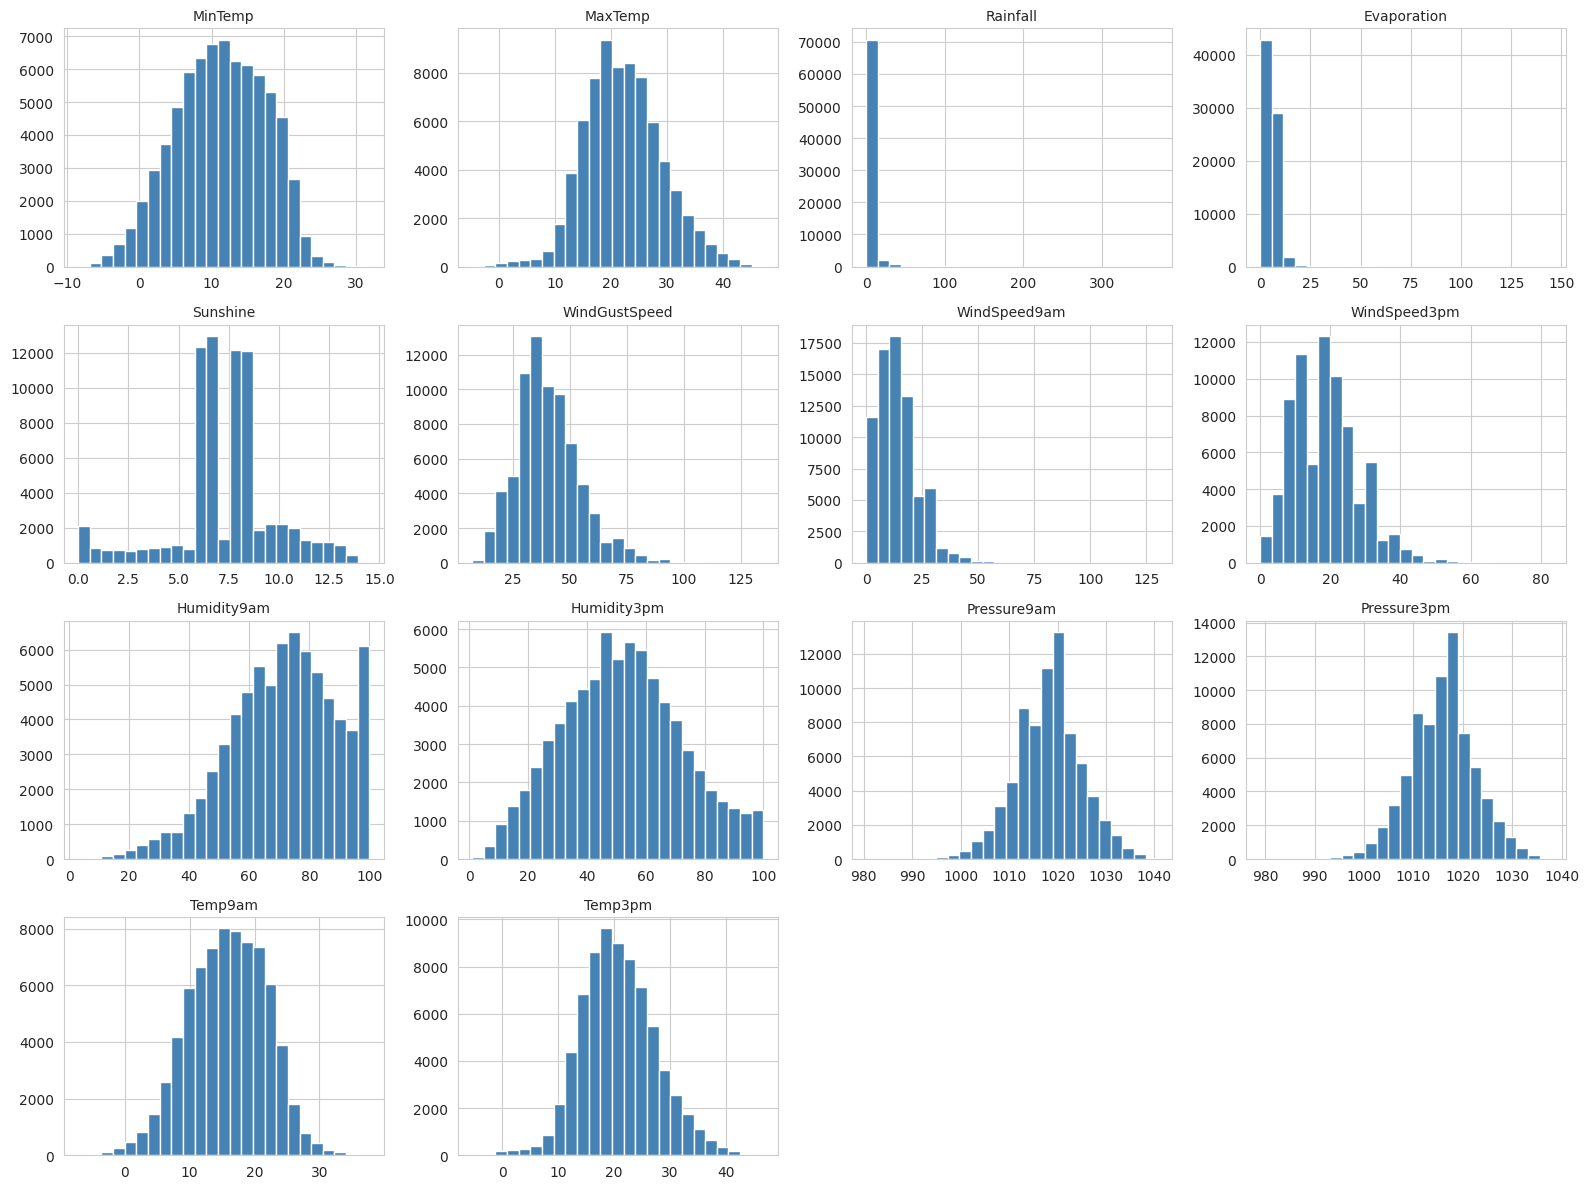

In [22]:
numeric_cols = df.select_dtypes(include=np.number).drop(['Spring', 'Summer', 'Autumn', 'Winter'], axis=1).columns.tolist()

n_cols = 4
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=25, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

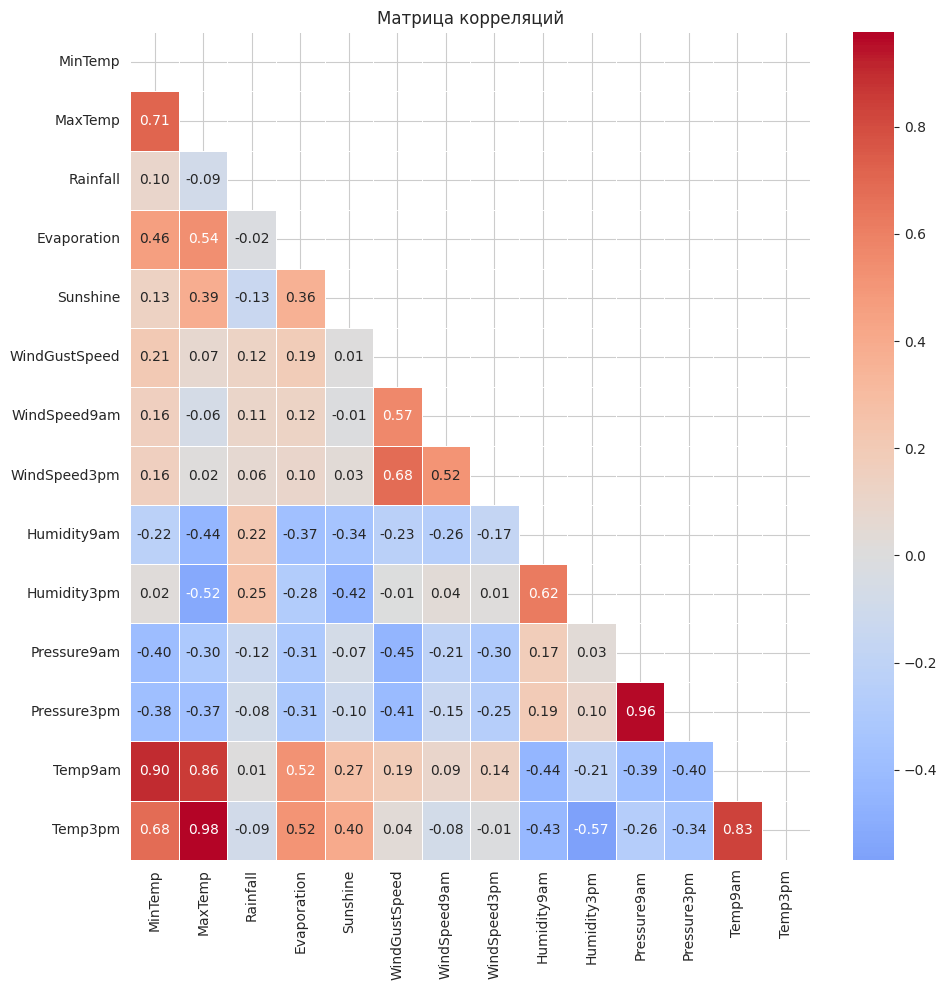

In [23]:
plt.figure(figsize=(10, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

In [24]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,Autumn,Spring,Summer,Winter
count,73884.00000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000,73884.000000
mean,11.24658,22.252587,2.346005,5.212797,7.355033,40.175868,13.879950,18.522591,71.126556,52.137852,1018.247942,1015.880649,15.791575,20.801031,0.242894,0.262763,0.252423,0.241920
std,6.21326,6.918290,8.229517,3.252908,2.555764,13.856440,9.319823,9.280702,17.753024,20.529901,6.695748,6.573807,6.027187,6.700090,0.428835,0.440138,0.434405,0.428249
min,-8.50000,-4.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,3.000000,1.000000,980.500000,979.000000,-7.200000,-5.400000,0.000000,0.000000,0.000000,0.000000
25%,6.80000,17.500000,0.000000,2.557526,5.992196,31.000000,7.000000,11.000000,60.000000,37.000000,1014.053335,1011.929399,11.500000,16.300000,0.000000,0.000000,0.000000,0.000000
50%,11.40000,21.800000,0.000000,4.368556,7.900000,39.000000,13.000000,17.376283,72.000000,52.000000,1018.400000,1016.000000,16.000000,20.400000,0.000000,0.000000,0.000000,0.000000
75%,16.10000,26.600000,0.800000,6.800000,8.656279,48.000000,19.000000,24.000000,84.000000,66.000000,1022.300000,1019.800000,20.300000,25.000000,0.000000,1.000000,1.000000,0.000000
max,31.90000,47.300000,371.000000,145.000000,14.500000,135.000000,130.000000,83.000000,100.000000,100.000000,1040.600000,1037.900000,37.700000,46.700000,1.000000,1.000000,1.000000,1.000000


In [25]:
df.drop(['MaxTemp', 'MinTemp', 'Pressure9am'], axis=1, inplace=True)

Кодирование "ветровых" признаков приведет к разрастанию датасета, поэтому будем их просто выбрасывать

In [26]:
df = df.dropna()

In [27]:
df.shape

(62856, 20)

Таким образом, после EDA и работы с пропусками потеряли порядка 10% данных, что не очень критично, если учесть изначально большой объем данных

##3. Регрессия и классификация

Для начала попробуем предсказывать RainTomorrow с помощью логистической регрессии и рещающего дерева, также попробуем добавить в пайплайн стандартизацию числовых признаков

In [28]:
df['RainToday'] = df['RainToday'].replace({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].replace({'No': 0, 'Yes': 1})
df.head()

,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Autumn,Spring,Summer,Winter
0,0.6,8.106034,8.656279,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.1,16.9,21.8,0,0,0,0,0,1
1,0.0,8.106034,8.656279,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1007.8,17.2,24.3,0,0,0,0,0,1
2,0.0,8.106034,8.656279,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1008.7,21.0,23.2,0,0,0,0,0,1
3,0.0,8.106034,8.656279,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1012.8,18.1,26.5,0,0,0,0,0,1
4,1.0,8.106034,8.656279,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1006.0,17.8,29.7,0,0,0,0,0,1


Создадим два набора данных - для классификации и для регресии

In [29]:
X_1 = df.drop(columns=['RainTomorrow', 'WindGustDir', 'WindDir9am', 'WindDir3pm'])
y_1 = df['RainTomorrow']

X_2 = df.drop(columns=['Temp3pm', 'RainTomorrow', 'WindGustDir', 'WindDir9am', 'WindDir3pm'])
y_2 = df['Temp3pm']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.25, stratify=y_1, random_state=0)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.25, random_state=0)

###3.1. Классификация

В качестве бейзлайна возьмем простую логистическую регрессию. После этого попробуем добавить к ней стандартизацию числовых признаков

In [31]:
lr_no_scale = Pipeline([
    ('clf', LogisticRegression(max_iter=1000, random_state=0))
])

lr_scale = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=0))
])

Логистическая регрессия

In [32]:
lr_no_scale.fit(X_train_1, y_train_1)
y_pred_lr_no_scale = lr_no_scale.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_lr_no_scale))
print('Precision :', precision_score(y_test_1, y_pred_lr_no_scale, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_lr_no_scale, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_lr_no_scale, zero_division=0))

Accuracy : 0.8416698485427008
Precision : 0.7088326675543719
Recall : 0.4657334499854185
F1 : 0.562126011967617


Логистическая регрессия с стандартизацией

In [33]:
lr_scale.fit(X_train_1, y_train_1)
y_pred_lr_scale = lr_scale.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_lr_scale))
print('Precision :', precision_score(y_test_1, y_pred_lr_scale, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_lr_scale, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_lr_scale, zero_division=0))

Accuracy : 0.8419880361461117
Precision : 0.7042314335060449
Recall : 0.4756488772236804
F1 : 0.5677980852915578


Видно, что добавление стандартизации существенно не повлияло на качество классификации

Теперь попробуем использовать для той же задачи решающие деревья.
Для решающих деревьев масштаб признаков неважен, проверим это на практике.

In [34]:
dt_no_scale = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=0))
])

dt_scale = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=0))
])

Решающее дерево

In [35]:
dt_no_scale.fit(X_train_1, y_train_1)
y_pred_dt_no_scale = dt_no_scale.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_dt_no_scale))
print('Precision :', precision_score(y_test_1, y_pred_dt_no_scale, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_dt_no_scale, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_dt_no_scale, zero_division=0))

Accuracy : 0.7796232658775614
Precision : 0.49533991228070173
Recall : 0.5269757946923301
F1 : 0.5106683623004098


Решающее дерево со стандартизацией

In [36]:
dt_scale.fit(X_train_1, y_train_1)
y_pred_dt_scale = dt_scale.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_dt_scale))
print('Precision :', precision_score(y_test_1, y_pred_dt_scale, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_dt_scale, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_dt_scale, zero_division=0))

Accuracy : 0.779814178439608
Precision : 0.4957499314505073
Recall : 0.5272674249052202
F1 : 0.5110231769361221


Действительно, метрики качества почти не изменились

А теперь попробуем с помощью кросс-валидации и поиска по сетке подобрать гиперпараметры для дерева

In [37]:
param_grid = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_1, y_train_1)
print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
0.5583886611000713


In [62]:
best_dt = grid_search.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_best_dt))
print('Precision :', precision_score(y_test_1, y_pred_best_dt, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_best_dt, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_best_dt, zero_division=0))

Accuracy : 0.8427516863942981
Precision : 0.7215541165587419
Recall : 0.4549431321084864
F1 : 0.5580397066714362


Подбор гиперпараметров дал ощутимый прирост качества

###3.2. Регрессия

В задаче регрессии будем предсказывать признак Temp3pm.  
В качестве бейзлайна возьмем обычную линейную модель с стандартизацией признаков

In [38]:
linear_scale = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', LinearRegression())
])

In [39]:
linear_scale.fit(X_train_2, y_train_2)
y_pred_linear_scale = linear_scale.predict(X_test_2)

print('MAE :', mean_absolute_error(y_test_2, y_pred_linear_scale))
print('MSE :', mean_squared_error(y_test_2, y_pred_linear_scale))
print('R2 :', r2_score(y_test_2, y_pred_linear_scale))

MAE : 1.4360333318939782
MSE : 3.565163339723168
R2 : 0.9243060526659661


Теперь попробуем добавить к линейной модели L1 и L2 регуляризации, штрафующие коэффициенты подберем с помощью поиска по сетке

In [40]:
lasso_scale = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', Lasso(random_state=0, max_iter=1000))
])

ridge_scale = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', Ridge(random_state=0, max_iter=1000))
])

Линейная регрессия с L1 регуляризацией

In [59]:
param_grid_lasso = {
    'regr__alpha': [0.1, 1, 10, 100]
}

grid_search_lasso = GridSearchCV(
    lasso_scale,
    param_grid_lasso,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_lasso.fit(X_train_2, y_train_2)

print(grid_search_lasso.best_params_)
print(-grid_search_lasso.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'regr__alpha': 0.1}
3.7333249813189964


Линейная регрессия с L2 регуляризацией

In [60]:
param_grid_ridge = {
    'regr__alpha': [0.1, 1, 10, 100]
}

grid_search_ridge = GridSearchCV(
    ridge_scale,
    param_grid_ridge,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_ridge.fit(X_train_2, y_train_2)

print(grid_search_ridge.best_params_)
print(-grid_search_ridge.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'regr__alpha': 1}
3.607460293824399


Удивительно, но регуляризация лишь ухудшила прогнозы модели. Это может быть связано с неподходящей сеткой перебора или, например, с физическими взаимосвязями признаков

В заключение, посмотрим на коэфициенты L1 регрессии, которая как раз и отбирает признаки

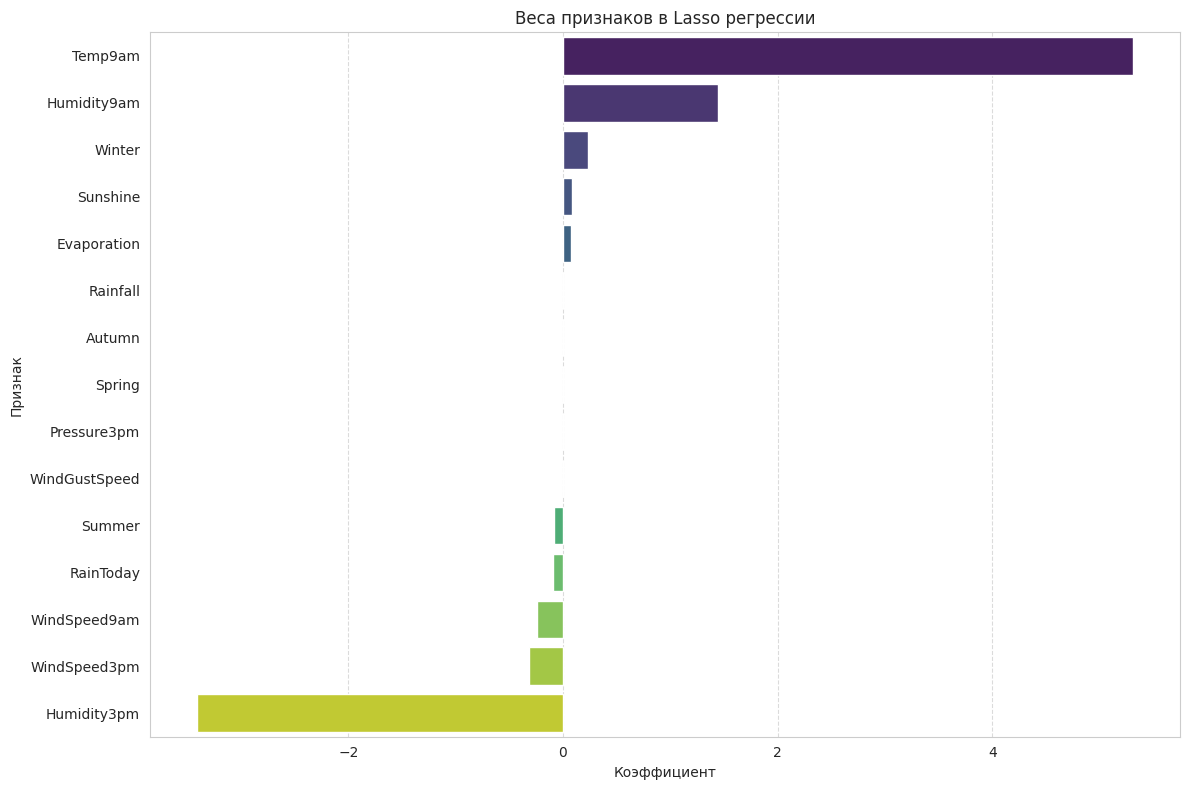

In [64]:
best_lasso_model = grid_search_lasso.best_estimator_.named_steps['regr']

lasso_coefficients = best_lasso_model.coef_
feature_names = X_train_2.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefficients
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Веса признаков в Lasso регрессии')
plt.xlabel('Коэффициент')
plt.ylabel('Признак')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Наиболее значимыми признаками L1 регрессия сочла Temp9am, Humidity9am, Humidity3pm - это легко объяснить физическими соображениями и временным характером этих признаков.  
Интересно, что L1 занулила признаки, отвечающие за времена года осень и весну - это говорит о том, что зимой и летом температуру прогнозировать гораздо проще, чем в переходные сезоны